<a href="https://colab.research.google.com/github/Love1117/Machine_learning-Projects/blob/main/Machine_Learning%20Project/05_Advanced%20Project%20(AI)/Recommendation%20System/Phones_Recommendation_System/Phone_recommendation_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

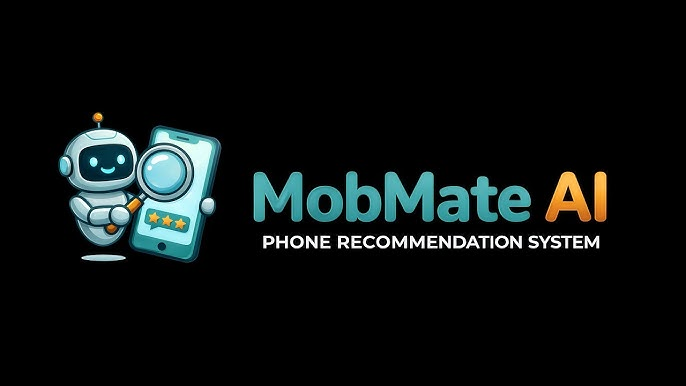
#**Project Summary:** Product Recommendation System Using Cosine Similarity

#**Overview**

This project implements a content-based phone recommendation system using text vectorization and cosine similarity. phone tags were transformed into numerical feature vectors, enabling the model to measure similarities between phone brand and recommend relevant items within the same category or closely related categories.
The system successfully generated accurate phones recommendations by identifying phone names with similar characteristics and customer relevance.


#**Aim of the Project:**
To build an intelligent recommendation engine that suggests relevant phones based on brand similarity.
To apply vectorization and cosine similarity techniques for phone matching and discovery.
To demonstrate how recommendation systems can enhance personalization and improve user shopping experiences.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


##**Load Data**

In [75]:
import pandas as pd

phone_data = pd.read_csv("/content/drive/My Drive/Datasets/flipkart_all_mobiles_final.csv")
phone_data.head()

,product_id,name,brand,price,mrp,discount,rating,ratings_reviews,ram,storage,display,camera,battery,processor,is_5g,highlights,image_url,product_url,source,source_page
0,MOBHN973FFYHGUGG,"MOTOROLA g06 power (Pantone tapestry, 64 GB)",MOTOROLA,"₹15,999","₹11,000",20% off,4.2,"17,454 Ratings",4 GB RAM,64 GB ROM,17.48 cm (6.88 inch) HD+ Display,50MP Rear Camera,7000 mAh Battery,Helio G81 Processor,No,Add to Compare | MOTOROLA g06 power (Pantone t...,https://rukminim2.flixcart.com/image/312/312/x...,https://www.flipkart.com/motorola-g06-power-pa...,category:mobiles; search:motorola mobiles,1
1,MOBH4DQF849HCG6G,"Apple iPhone 16 (White, 128 GB)",Apple,"₹69,900","₹48,650",NaN,4.6,"1,93,584 Ratings",NaN,128 GB ROM,15.49 cm (6.1 inch) Super Retina XDR Display,12MP Front Camera,NaN,NaN,No,"Add to Compare | Apple iPhone 16 (White, 128 G...",https://rukminim2.flixcart.com/image/312/312/x...,https://www.flipkart.com/apple-iphone-16-white...,category:mobiles; search:mobile phones; search...,1
2,MOBGWZUWPTFTQZAH,"Nokia 105 Classic Single Sim Keypad Phone, Wit...",Nokia,"₹1,054",₹300,21% off,4.5,"16,585 Ratings",NaN,NaN,4.5 cm (1.77 inch) Display,0MP Front Camera,800 mAh Battery,NaN,No,Add to Compare | Nokia 105 Classic Single Sim ...,https://rukminim2.flixcart.com/image/312/312/x...,https://www.flipkart.com/nokia-105-classic-sin...,category:mobiles; search:nokia mobiles,1
3,MOBHH69NRE6PHFBH,"vivo T5x 5G (Star Silver, 128 GB)",vivo,"₹22,999","₹16,350",20% off,4.3,"8,063 Ratings",6 GB RAM,128 GB ROM,17.17 cm (6.76 inch) Display,32MP Front Camera,7200 mAh Li-ion Battery,Dimensity 7400-Turbo Processor,Yes,"Add to Compare | vivo T5x 5G (Star Silver, 128...",https://rukminim2.flixcart.com/image/312/312/x...,https://www.flipkart.com/vivo-t5x-5g-star-silv...,category:mobiles; search:mobile phones; search...,1
4,MOBHFN6YN2HXB5HE,"Apple iPhone 17 (Black, 256 GB)",Apple,"₹82,900","₹48,650",NaN,4.6,"12,927 Ratings",NaN,256 GB ROM,16.0 cm (6.3 inch) Super Retina XDR Display,18MP Front Camera,NaN,NaN,No,"Add to Compare | Apple iPhone 17 (Black, 256 G...",https://rukminim2.flixcart.com/image/312/312/x...,https://www.flipkart.com/apple-iphone-17-black...,category:mobiles; search:iphone,1


##**Feature engineering**

In [76]:
phone_data.drop(columns=["product_id", "is_5g", "highlights", "product_url", "source", "source_page"], inplace=True)
phone_data.dropna(inplace=True)
phone_data.rename(columns=({"price":"market_price", "mrp":"Sale_Price"}),inplace=True )
phone_data["tags"] = phone_data["name"] + "_" + phone_data["ram"] + "_" + phone_data["storage"] + "_" + phone_data["display"] + "_" + phone_data["camera"] + "_" + phone_data["battery"] + "_" + phone_data["processor"]
phone_data.drop(columns=["ram", "storage", "display", "camera", "battery", "processor"], inplace=True)

phone_data.head()

,name,brand,market_price,Sale_Price,discount,rating,ratings_reviews,image_url,tags
0,"MOTOROLA g06 power (Pantone tapestry, 64 GB)",MOTOROLA,"₹15,999","₹11,000",20% off,4.2,"17,454 Ratings",https://rukminim2.flixcart.com/image/312/312/x...,"MOTOROLA g06 power (Pantone tapestry, 64 GB)_4..."
3,"vivo T5x 5G (Star Silver, 128 GB)",vivo,"₹22,999","₹16,350",20% off,4.3,"8,063 Ratings",https://rukminim2.flixcart.com/image/312/312/x...,"vivo T5x 5G (Star Silver, 128 GB)_6 GB RAM_128..."
5,"realme P4 Lite 5G (Mosaic Green, 64 GB)",realme,"₹14,999","₹10,350",25% off,4.3,"4,937 Ratings",https://rukminim2.flixcart.com/image/312/312/x...,"realme P4 Lite 5G (Mosaic Green, 64 GB)_4 GB R..."
7,REDMI Note 15 SE 5G Snapdragon (Crimson Reserv...,REDMI,"₹22,999","₹16,350",34% off,4.3,"1,930 Ratings",https://rukminim2.flixcart.com/image/312/312/x...,REDMI Note 15 SE 5G Snapdragon (Crimson Reserv...
8,"MOTOROLA Edge 70 Fusion (Pantone COUNTRY AIR, ...",MOTOROLA,"₹30,999","₹22,150",27% off,4.4,"8,423 Ratings",https://rukminim2.flixcart.com/image/312/312/x...,"MOTOROLA Edge 70 Fusion (Pantone COUNTRY AIR, ..."


In [77]:
import numpy as np

phone_data["market_price"] = phone_data["market_price"].astype(str).str.strip("₹").str.replace(",", "").astype(int)
phone_data["Sale_Price"] = phone_data["Sale_Price"].astype(str).str.strip("₹").str.replace(",", "").astype(int)
phone_data["ratings_reviews"] = phone_data["ratings_reviews"].str.replace(" Ratings", "")

# convert from indiam rupe
e to usd
phone_data["market_price"] = (phone_data["market_price"]/86.000).round(2)
phone_data["Sale_Price"] = (phone_data["Sale_Price"]/86.00).round(2)

# Apply conditional formatting for display
phone_data["market_price"] = np.where(phone_data["market_price"] > 999.99, phone_data["market_price"].apply(lambda x: f"{x:,.2f}"), phone_data["market_price"])
phone_data["Sale_Price"] = np.where(phone_data["Sale_Price"] > 999.99, phone_data["Sale_Price"].apply(lambda x: f"{x:,.2f}"), phone_data["Sale_Price"])

phone_data.head()

,name,brand,market_price,Sale_Price,discount,rating,ratings_reviews,image_url,tags
0,"MOTOROLA g06 power (Pantone tapestry, 64 GB)",MOTOROLA,186.03,127.91,20% off,4.2,"17,454",https://rukminim2.flixcart.com/image/312/312/x...,"MOTOROLA g06 power (Pantone tapestry, 64 GB)_4..."
3,"vivo T5x 5G (Star Silver, 128 GB)",vivo,267.43,190.12,20% off,4.3,"8,063",https://rukminim2.flixcart.com/image/312/312/x...,"vivo T5x 5G (Star Silver, 128 GB)_6 GB RAM_128..."
5,"realme P4 Lite 5G (Mosaic Green, 64 GB)",realme,174.41,120.35,25% off,4.3,"4,937",https://rukminim2.flixcart.com/image/312/312/x...,"realme P4 Lite 5G (Mosaic Green, 64 GB)_4 GB R..."
7,REDMI Note 15 SE 5G Snapdragon (Crimson Reserv...,REDMI,267.43,190.12,34% off,4.3,"1,930",https://rukminim2.flixcart.com/image/312/312/x...,REDMI Note 15 SE 5G Snapdragon (Crimson Reserv...
8,"MOTOROLA Edge 70 Fusion (Pantone COUNTRY AIR, ...",MOTOROLA,360.45,257.56,27% off,4.4,"8,423",https://rukminim2.flixcart.com/image/312/312/x...,"MOTOROLA Edge 70 Fusion (Pantone COUNTRY AIR, ..."


In [80]:
phone_data["tags"] = phone_data["tags"].str.replace("\n", " ")
phone_data["tags"] = phone_data["tags"].str.replace("\t", " ")
phone_data["tags"] = phone_data["tags"].apply(lambda x: x.lower())
phone_data["tags"]

,tags
0,"motorola g06 power (pantone tapestry, 64 gb)_4..."
3,"vivo t5x 5g (star silver, 128 gb)_6 gb ram_128..."
5,"realme p4 lite 5g (mosaic green, 64 gb)_4 gb r..."
7,redmi note 15 se 5g snapdragon (crimson reserv...
8,"motorola edge 70 fusion (pantone country air, ..."
...,...
5883,currently unavailable add to compare nothing p...
5887,currently unavailable add to compare redmi 13c...
5889,"poco c55 (power black, 64 gb)_4 gb ram_64 gb r..."
5892,currently unavailable add to compare poco c55 ...


##**Importing TfidfVectorizer to vectorize our tags**

In [91]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf  = TfidfVectorizer(analyzer="word", stop_words="english")
vector = tfidf.fit_transform(phone_data["tags"])
vector.shape

(886, 796)

##**Importing cosine_similarity to find the nearest word in meaning**

In [83]:
from sklearn.metrics.pairwise import cosine_similarity

In [99]:
def get_recommendations(brand):
  def strikethrough_text(text):
      return ''.join([char + '\u0336' for char in str(text)])

  idx = phone_data[phone_data["brand"].str.lower() == brand.lower()].index[0]
  sim_scores = sorted(list(enumerate(cosine_similarity(vector[idx], vector).flatten())), reverse=True,  key= lambda item: item[1])
  for i in sim_scores[1:11]:
    market_price_formatted = strikethrough_text(phone_data.iloc[i[0]]['market_price'])
    print(f"Image URL: {phone_data.iloc[i[0]]['image_url']}\nProduct Name: {phone_data.iloc[i[0]]['name']}\nReviews: {phone_data.iloc[i[0]]['rating']} out of 5 stars ({phone_data.iloc[i[0]]['ratings_reviews']}) Total comments \nSale Price:{phone_data.iloc[i[0]]['discount']}   ${phone_data.iloc[i[0]]['Sale_Price']}\nMarket Price: ${market_price_formatted}\n")

In [100]:
print(get_recommendations("MOTOROLA"))

Image URL: https://rukminim2.flixcart.com/image/312/312/xif0q/mobile/0/x/b/-original-imahng9fvudxxrgm.jpeg?q=70
Product Name: MOTOROLA g06 power (Pantone Tendril, 64 GB)
Reviews: 4.2 out of 5 stars (17,454) Total comments 
Sale Price:20% off   $127.91
Market Price: $1̶8̶6̶.̶0̶3̶

Image URL: https://rukminim2.flixcart.com/image/312/312/xif0q/mobile/i/v/5/-original-imahnfuyg5jccfv8.jpeg?q=70
Product Name: MOTOROLA g06 power (Pantone Laurel Oak, 64 GB)
Reviews: 4.2 out of 5 stars (17,454) Total comments 
Sale Price:20% off   $127.91
Market Price: $1̶8̶6̶.̶0̶3̶

Image URL: https://rukminim2.flixcart.com/image/312/312/xif0q/mobile/j/a/b/-original-imah83eztbdcsknu.jpeg?q=70
Product Name: MOTOROLA g05 (Forest Green, 64 GB)
Reviews: 4.2 out of 5 stars (81,860) Total comments 
Sale Price:27% off   $53.49
Market Price: $8̶4̶.̶8̶7̶

Image URL: https://rukminim2.flixcart.com/image/312/312/xif0q/mobile/d/j/b/-original-imah83ezvx8m7hs6.jpeg?q=70
Product Name: MOTOROLA g05 (Plum Red, 64 GB)
Reviews: 

#**Conclusion / Deployment Summary**

##**When deployed, this recommendation system can:**

* Recommend relevant phones in real time based on user interests or selected items.

* Improve phones discovery, cross-selling, and customer engagement on e-commerce platforms.

* Support personalized shopping experiences by delivering data-driven recommendations.


This project demonstrates practical expertise in recommendation systems, feature engineering, and similarity-based machine learning solutions commonly used in modern e-commerce applications.